#### Importing libraries

In [68]:
import tkinter as tk
from tkinter import ttk, messagebox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import calendar

#### Files

In [69]:
HOUSE_FILES = {
    "1 RK": "appliances_1RK.csv",
    "1 BHK": "appliances_1BHK.csv",
    "1.5 BHK": "appliances_15BHK.csv",
    "2 BHK": "appliances_2BHK.csv",
    "2.5 BHK": "appliances_25BHK.csv",
    "3 BHK": "appliances_3BHK.csv",
}
DATA_DIR = "./" 

def load_house_data(house_type):
    df = pd.read_csv(rf"data\{HOUSE_FILES[house_type]}")
    df = df[df["count"] > 0].reset_index(drop=True)
    records = df.to_dict("records")
    for r in records:
        r["hours"] = r.pop("default_hours")
    return records

#### Cost + seasonal logic

In [70]:
# Official MSEDCL Residential (LT-1) Slabs & Energy Charges (₹ per unit)
# Format: (cumulative_unit_limit, rate_for_that_slab)
PUNE_SLABS = [
    (100, 4.28),        # 0 to 100 units
    (300, 11.10),       # 101 to 300 units
    (500, 15.38),       # 301 to 500 units
    (float("inf"), 17.68) # Above 500 units
]

def calculate_energy_charge(units, slabs=PUNE_SLABS):
    """Calculates telescopically accurate bill energy charges based on MSEDCL slabs."""
    if units <= 0:
        return 0.0
    
    remaining, prev_limit, cost = units, 0, 0.0
    for limit, rate in slabs:
        slab_capacity = limit if limit == float("inf") else (limit - prev_limit)
        slab_units = min(remaining, slab_capacity)
        
        if slab_units <= 0:
            break
            
        cost += slab_units * rate
        remaining -= slab_units
        prev_limit = limit
        
        if remaining <= 0:
            break
            
    return round(cost, 2)

def calculate_full_bill(units, connection_type="Single-Phase", fac_rate=0.35):
    """Returns a breakdown dict: energy charge + wheeling + FAC, then duty on top, plus fixed charge."""
    energy_charge = calculate_energy_charge(units)
    wheeling = round(units * 1.60, 2)
    fac = round(units * fac_rate, 2)
    subtotal = energy_charge + wheeling + fac
    duty = round(subtotal * 0.16, 2)
    fixed = 130.0 if connection_type == "Single-Phase" else 435.0
    total = round(subtotal + duty + fixed, 2)
    return {
        "energy_charge": energy_charge, "wheeling": wheeling, "fac": fac,
        "duty": duty, "fixed": fixed, "total": total,
    }

# Seasonal grouping for the season filter
SEASONS = {
    "Summer (Mar–Jun)": [3, 4, 5, 6],
    "Monsoon (Jul–Sep)": [7, 8, 9],
    "Winter (Oct–Feb)": [10, 11, 12, 1, 2],
}

SEASONAL_FACTORS = {
    "Air Conditioner": {3:1.3, 4:1.7, 5:1.9, 6:1.7, 7:1.3, 8:1.2, 9:1.1, 10:0.9, 11:0.4, 12:0.3, 1:0.3, 2:0.5},
    "Air Cooler":      {3:1.3, 4:1.6, 5:1.8, 6:1.6, 7:1.2, 8:1.1, 9:1.0, 10:0.8, 11:0.4, 12:0.3, 1:0.3, 2:0.5},
    "Space Heater":    {11:1.3, 12:1.8, 1:1.9, 2:1.4, 3:0.6, 10:0.3},
    "Water Heater":    {11:1.2, 12:1.5, 1:1.6, 2:1.3, 3:1.0, 10:0.9},
    "Ceiling Fan":     {4:1.2, 5:1.3, 6:1.3, 7:1.1, 8:1.1},
}

def seasonal_factor(name, month):
    return SEASONAL_FACTORS.get(name, {}).get(month, 1.0)

def daily_kwh(appliance):
    return appliance["power_w"] * appliance["count"] * appliance["hours"] / 1000

def monthly_kwh(appliances, month):
    return round(sum(daily_kwh(a) * 30 * seasonal_factor(a["name"], month) for a in appliances), 2)

def yearly_breakdown(appliances):
    return {m: monthly_kwh(appliances, m) for m in range(1, 13)}

#### Screen 1: House type selection

In [71]:
HOUSE_DESCRIPTIONS = {
    "1 RK": "Single room + kitchen. Lowest footprint.",
    "1 BHK": "1 Bedroom, Hall, Kitchen. Compact household.",
    "1.5 BHK": "1 BHK + small extra room/study.",
    "2 BHK": "2 Bedrooms, Hall, Kitchen. Standard family home.",
    "2.5 BHK": "2 BHK + small extra room. More appliances.",
    "3 BHK": "3 Bedrooms, Hall, Kitchen. Larger household.",
}

class HouseSelectScreen(tk.Frame):
    def __init__(self, parent, controller):
        super().__init__(parent, bg="#F4F6F8")
        self.controller = controller

        tk.Label(self, text="Household Electricity Consumption Analyzer",
                 font=("Segoe UI", 20, "bold"), bg="#F4F6F8", fg="#1B5E20").pack(pady=(50, 4))
        tk.Label(self, text="Select your house type to get started",
                 font=("Segoe UI", 11), bg="#F4F6F8", fg="#546E7A").pack(pady=(0, 30))

        grid = tk.Frame(self, bg="#F4F6F8")
        grid.pack()

        cols = 3
        for i, house in enumerate(HOUSE_FILES):
            r, c = divmod(i, cols)
            self._make_card(grid, house).grid(row=r, column=c, padx=14, pady=14, sticky="nsew")

    def _make_card(self, parent, house):
        card = tk.Frame(parent, bg="#FFFFFF", bd=0, highlightthickness=1,
                         highlightbackground="#CFD8DC", width=220, height=140)
        card.grid_propagate(False)
        card.pack_propagate(False)

        title = tk.Label(card, text=house, font=("Segoe UI", 14, "bold"),
                          bg="#FFFFFF", fg="#263238")
        title.pack(pady=(18, 6))

        desc = tk.Label(card, text=HOUSE_DESCRIPTIONS.get(house, ""), font=("Segoe UI", 9),
                         bg="#FFFFFF", fg="#78909C", wraplength=180, justify="center")
        desc.pack(pady=(0, 10), padx=10)

        select_btn = tk.Label(card, text="Select →", font=("Segoe UI", 9, "bold"),
                               bg="#FFFFFF", fg="#2E7D32")
        select_btn.pack()

        widgets = [card, title, desc, select_btn]

        def on_enter(e):
            card.config(bg="#E8F5E9", highlightbackground="#2E7D32")
            for w in widgets:
                if w is not card:
                    w.config(bg="#E8F5E9")

        def on_leave(e):
            card.config(bg="#FFFFFF", highlightbackground="#CFD8DC")
            for w in widgets:
                if w is not card:
                    w.config(bg="#FFFFFF")

        def on_click(e):
            self.select(house)

        for w in widgets:
            w.bind("<Enter>", on_enter)
            w.bind("<Leave>", on_leave)
            w.bind("<Button-1>", on_click)
            w.config(cursor="hand2")

        return card

    def select(self, house):
        self.controller.house_type = house
        self.controller.appliances = load_house_data(house)
        self.controller.show_frame(ApplianceEditScreen)

#### Screen 2: Appliance editor (+ Add/Edit dialog)

In [72]:
class ApplianceDialog(tk.Toplevel):
    def __init__(self, parent_screen, controller, mode="add", index=None):
        super().__init__(parent_screen)
        self.title("Add Appliance" if mode == "add" else "Edit Appliance")
        self.geometry("320x380")
        self.controller = controller
        self.parent_screen = parent_screen
        self.mode = mode
        self.index = index

        existing = controller.appliances[index] if mode == "edit" else {
            "name": "", "type": "", "category": "Custom", "power_w": 100, "hours": 1.0,
            "count": 1, "continuous": False}

        fields = [("name", "Name"), ("type", "Type/Model"), ("category", "Category"),
                  ("power_w", "Power (Watts)"), ("hours", "Hours Used / Day"), ("count", "Quantity")]
        self.vars = {}
        for i, (key, label) in enumerate(fields):
            tk.Label(self, text=label).grid(row=i, column=0, sticky="w", padx=10, pady=6)
            var = tk.StringVar(value=str(existing.get(key, "")))
            tk.Entry(self, textvariable=var).grid(row=i, column=1, padx=10)
            self.vars[key] = var

        self.continuous_var = tk.BooleanVar(value=bool(existing.get("continuous", False)))
        tk.Checkbutton(self, text="Runs continuously (24 hrs, e.g. fridge)",
                       variable=self.continuous_var).grid(row=len(fields), column=0, columnspan=2, pady=8)

        tk.Button(self, text="Save", bg="#4CAF50", fg="white", command=self.save).grid(
            row=len(fields) + 1, column=0, columnspan=2, pady=12)

    def save(self):
        try:
            appliance = {
                "name": self.vars["name"].get().strip() or "Unnamed Appliance",
                "type": self.vars["type"].get().strip(),
                "category": self.vars["category"].get().strip() or "Custom",
                "power_w": float(self.vars["power_w"].get()),
                "hours": float(self.vars["hours"].get()),
                "count": int(self.vars["count"].get()),
                "continuous": self.continuous_var.get(),
            }
        except ValueError:
            messagebox.showerror("Invalid input", "Power, hours and quantity must be numbers.")
            return

        if self.mode == "add":
            self.controller.appliances.append(appliance)
        else:
            self.controller.appliances[self.index] = appliance

        self.parent_screen.refresh_table()
        self.destroy()


class ApplianceEditScreen(tk.Frame):
    def __init__(self, parent, controller):
        super().__init__(parent)
        self.controller = controller

        tk.Label(self, text="Your Appliances", font=("Segoe UI", 16, "bold")).pack(pady=10)

        cols = ("name", "type", "category", "power_w", "hours", "count", "continuous")
        self.tree = ttk.Treeview(self, columns=cols, show="headings", height=15)
        for c in cols:
            self.tree.heading(c, text=c.replace("_", " ").title())
            self.tree.column(c, width=110, anchor="center")
        self.tree.pack(fill="both", expand=True, padx=15, pady=5)

        btns = tk.Frame(self)
        btns.pack(pady=8)
        tk.Button(btns, text="Add Custom Item", width=15, command=self.add_item).grid(row=0, column=0, padx=5)
        tk.Button(btns, text="Edit Selected", width=15, command=self.edit_item).grid(row=0, column=1, padx=5)
        tk.Button(btns, text="Delete Selected", width=15, command=self.delete_item).grid(row=0, column=2, padx=5)
        tk.Button(btns, text="Reset to Default", width=15, command=self.reset_items).grid(row=0, column=3, padx=5)
        tk.Button(btns, text="← Back", width=10,
                  command=lambda: controller.show_frame(HouseSelectScreen)).grid(row=0, column=4, padx=5)
        tk.Button(btns, text="Continue to Dashboard →", width=22, bg="#4CAF50", fg="white",
                  command=self.go_dashboard).grid(row=0, column=5, padx=5)

    def on_show(self):
        self.refresh_table()

    def refresh_table(self):
        self.tree.delete(*self.tree.get_children())
        for i, a in enumerate(self.controller.appliances):
            self.tree.insert("", "end", iid=str(i), values=(
                a["name"], a.get("type", ""), a.get("category", "Custom"),
                a["power_w"], a["hours"], a["count"], a["continuous"]))

    def get_selected_index(self):
        sel = self.tree.selection()
        if not sel:
            messagebox.showinfo("Select an item", "Please select an appliance first.")
            return None
        return int(sel[0])

    def add_item(self):
        ApplianceDialog(self, self.controller, mode="add")

    def edit_item(self):
        idx = self.get_selected_index()
        if idx is not None:
            ApplianceDialog(self, self.controller, mode="edit", index=idx)

    def delete_item(self):
        idx = self.get_selected_index()
        if idx is not None:
            del self.controller.appliances[idx]
            self.refresh_table()

    def reset_items(self):
        if messagebox.askyesno("Reset", "Reset all appliances to default for this house type?"):
            self.controller.appliances = load_house_data(self.controller.house_type)
            self.refresh_table()

    def go_dashboard(self):
        if not self.controller.appliances:
            messagebox.showwarning("No appliances", "Add at least one appliance first.")
            return
        self.controller.show_frame(DashboardScreen)

#### Screen 3: Dashboard

In [73]:
# ---- Theme constants for charts ----
PRIMARY = "#2E7D32"      # green
PRIMARY_LIGHT = "#A5D6A7"
ACCENT = "#00838F"       # teal
MUTED = "#B0BEC5"        # grey (non-highlighted data)
DARK = "#263238"
BG = "#F4F6F8"
CARD_BG = "#FFFFFF"
BORDER = "#E0E0E0"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "axes.edgecolor": BORDER,
    "axes.labelcolor": "#546E7A",
    "text.color": DARK,
    "xtick.color": "#546E7A",
    "ytick.color": "#546E7A",
    "figure.facecolor": CARD_BG,
    "axes.facecolor": CARD_BG,
})

BILL_COMPONENT_COLORS = [PRIMARY, ACCENT, "#F9A825", "#78909C", "#455A64"]


class DashboardScreen(tk.Frame):
    def __init__(self, parent, controller):
        super().__init__(parent, bg=BG)
        self.controller = controller

        # ---- Title ----
        tk.Label(self, text="Electricity Dashboard — Pune / PCMC (MSEDCL)",
                 font=("Segoe UI", 15, "bold"), bg=BG, fg=DARK).pack(pady=(12, 0))

        # ---- Filter bar (row 1: billing settings) ----
        row1 = tk.Frame(self, bg=BG)
        row1.pack(fill="x", padx=15, pady=(10, 2))

        tk.Label(row1, text="Connection:", bg=BG, font=("Segoe UI", 10)).pack(side="left", padx=(0, 4))
        self.conn_var = tk.StringVar(value="Single-Phase")
        ttk.Combobox(row1, textvariable=self.conn_var, values=["Single-Phase", "Three-Phase"],
                     state="readonly", width=13).pack(side="left", padx=(0, 15))
        self.conn_var.trace_add("write", lambda *a: self.refresh())

        tk.Label(row1, text="FAC rate (₹/unit):", bg=BG, font=("Segoe UI", 10)).pack(side="left", padx=(0, 4))
        self.fac_var = tk.StringVar(value="0.35")
        fac_entry = tk.Entry(row1, textvariable=self.fac_var, width=6)
        fac_entry.pack(side="left", padx=(0, 15))
        fac_entry.bind("<Return>", lambda e: self.refresh())
        fac_entry.bind("<FocusOut>", lambda e: self.refresh())

        tk.Button(row1, text="← Edit Appliances", bg="#607D8B", fg="white", relief="flat",
                  font=("Segoe UI", 9, "bold"), padx=10,
                  command=lambda: controller.show_frame(ApplianceEditScreen)).pack(side="right")

        # ---- Filter bar (row 2: period + category) ----
        row2 = tk.Frame(self, bg=BG)
        row2.pack(fill="x", padx=15, pady=(2, 10))

        tk.Label(row2, text="View:", bg=BG, font=("Segoe UI", 10)).pack(side="left", padx=(0, 4))
        self.view_mode_var = tk.StringVar(value="Month")
        view_menu = ttk.Combobox(row2, textvariable=self.view_mode_var, values=["Month", "Season", "Full Year"],
                                  state="readonly", width=10)
        view_menu.pack(side="left", padx=(0, 15))
        view_menu.bind("<<ComboboxSelected>>", lambda e: self.refresh())

        tk.Label(row2, text="Month:", bg=BG, font=("Segoe UI", 10)).pack(side="left", padx=(0, 4))
        self.month_var = tk.StringVar(value=calendar.month_name[1])
        month_menu = ttk.Combobox(row2, textvariable=self.month_var, values=list(calendar.month_name)[1:],
                                   state="readonly", width=11)
        month_menu.pack(side="left", padx=(0, 15))
        month_menu.bind("<<ComboboxSelected>>", lambda e: self.refresh())

        tk.Label(row2, text="Season:", bg=BG, font=("Segoe UI", 10)).pack(side="left", padx=(0, 4))
        self.season_var = tk.StringVar(value=list(SEASONS.keys())[0])
        season_menu = ttk.Combobox(row2, textvariable=self.season_var, values=list(SEASONS.keys()),
                                    state="readonly", width=16)
        season_menu.pack(side="left", padx=(0, 15))
        season_menu.bind("<<ComboboxSelected>>", lambda e: self.refresh())

        tk.Label(row2, text="Category:", bg=BG, font=("Segoe UI", 10)).pack(side="left", padx=(0, 4))
        self.category_var = tk.StringVar(value="All")
        self.category_menu = ttk.Combobox(row2, textvariable=self.category_var, values=["All"],
                                           state="readonly", width=16)
        self.category_menu.pack(side="left")
        self.category_menu.bind("<<ComboboxSelected>>", lambda e: self.refresh())

        # ---- KPI cards row ----
        self.kpi_frame = tk.Frame(self, bg=BG)
        self.kpi_frame.pack(fill="x", padx=15, pady=(0, 10))

        # ---- Charts (2x2, roomier) ----
        self.fig, self.axes = plt.subplots(2, 2, figsize=(13, 7.5))
        self.canvas = FigureCanvasTkAgg(self.fig, master=self)
        self.canvas.get_tk_widget().pack(fill="both", expand=True, padx=15, pady=(0, 12))

    def on_show(self):
        cats = sorted({a["category"] for a in self.controller.appliances})
        self.category_menu["values"] = ["All"] + cats
        if self.category_var.get() not in (["All"] + cats):
            self.category_var.set("All")
        self.refresh()

    def _period_months(self):
        mode = self.view_mode_var.get()
        if mode == "Month":
            m = list(calendar.month_name).index(self.month_var.get())
            return [m], self.month_var.get()
        elif mode == "Season":
            season = self.season_var.get()
            return SEASONS[season], season
        else:
            return list(range(1, 13)), "Full Year"

    def _style_ax(self, ax, title):
        ax.set_title(title, fontsize=11, fontweight="bold", color=DARK, pad=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.tick_params(left=False)
        ax.grid(axis="x", alpha=0.2, color=MUTED)
        ax.set_axisbelow(True)

    # ---- KPI cards ----
    def _build_kpis(self, values):
        for w in self.kpi_frame.winfo_children():
            w.destroy()

        cards = [
            ("Total Units", f"{values['units']:.0f} kWh", PRIMARY),
            ("Total Bill", f"₹ {values['cost']:.0f}", ACCENT),
            ("Avg Daily Cost", f"₹ {values['avg_daily']:.0f}", "#F9A825"),
            ("Top Category", values['top_category'], "#455A64"),
        ]
        for i, (label, value, accent) in enumerate(cards):
            card = tk.Frame(self.kpi_frame, bg=CARD_BG, highlightthickness=1, highlightbackground=BORDER)
            card.grid(row=0, column=i, sticky="nsew", padx=(0 if i == 0 else 8, 0))
            self.kpi_frame.grid_columnconfigure(i, weight=1)

            bar = tk.Frame(card, bg=accent, width=4)
            bar.pack(side="left", fill="y")
            inner = tk.Frame(card, bg=CARD_BG)
            inner.pack(side="left", fill="both", expand=True, padx=14, pady=10)
            tk.Label(inner, text=label, font=("Segoe UI", 9), bg=CARD_BG, fg="#78909C").pack(anchor="w")
            tk.Label(inner, text=value, font=("Segoe UI", 15, "bold"), bg=CARD_BG, fg=DARK).pack(anchor="w")

    def refresh(self):
        all_appliances = self.controller.appliances
        cat = self.category_var.get()
        filtered = all_appliances if cat == "All" else [a for a in all_appliances if a["category"] == cat]

        try:
            fac_rate = float(self.fac_var.get())
        except ValueError:
            fac_rate = 0.35
        conn = self.conn_var.get()

        period_months, period_label = self._period_months()

        monthly_filtered = {m: monthly_kwh(filtered, m) for m in range(1, 13)}
        monthly_bill_filtered = {m: calculate_full_bill(monthly_filtered[m], conn, fac_rate)["total"]
                                  for m in range(1, 13)}

        period_units = sum(monthly_filtered[m] for m in period_months)
        period_bills = [calculate_full_bill(monthly_filtered[m], conn, fac_rate) for m in period_months]
        period_cost = sum(b["total"] for b in period_bills)
        breakdown_sum = {k: round(sum(b[k] for b in period_bills), 2)
                          for k in ["energy_charge", "wheeling", "fac", "duty", "fixed"]}

        # Category totals for period (full appliance set, for context + top category KPI)
        cat_kwh_all = {}
        for a in all_appliances:
            k = sum(daily_kwh(a) * 30 * seasonal_factor(a["name"], m) for m in period_months)
            cat_kwh_all[a["category"]] = cat_kwh_all.get(a["category"], 0) + k
        top_category = max(cat_kwh_all, key=cat_kwh_all.get) if cat_kwh_all else "—"

        avg_daily = period_cost / (30 * len(period_months)) if period_months else 0

        self._build_kpis({
            "units": period_units, "cost": period_cost,
            "avg_daily": avg_daily, "top_category": top_category,
        })

        for row in self.axes:
            for ax in row:
                ax.clear()
        ax1, ax2 = self.axes[0]
        ax3, ax4 = self.axes[1]
        months_abbr = list(calendar.month_abbr)[1:]

        # --- 1. Monthly bill — clean bar, only period bars colored ---
        costs = [monthly_bill_filtered[m] for m in range(1, 13)]
        colors = [PRIMARY if m in period_months else MUTED for m in range(1, 13)]
        bars = ax1.bar(months_abbr, costs, color=colors, width=0.6)
        for m in period_months:
            ax1.text(m - 1, costs[m - 1], f"₹{costs[m-1]:.0f}", ha="center", va="bottom",
                      fontsize=8, color=PRIMARY, fontweight="bold")
        self._style_ax(ax1, "Monthly Bill — Filtered Set (₹)")

        # --- 2. Category breakdown — horizontal bar, sorted, single-hue gradient ---
        sorted_cats = sorted(cat_kwh_all.items(), key=lambda x: x[1])
        if sorted_cats:
            names, vals = zip(*sorted_cats)
            shades = plt.cm.Greens([0.4 + 0.5 * (i / max(len(vals) - 1, 1)) for i in range(len(vals))])
            ax2.barh(names, vals, color=shades)
        self._style_ax(ax2, f"Consumption by Category — {period_label}")
        ax2.set_xlabel("kWh")

        # --- 3. Top 5 appliances — horizontal bar, single accent hue ---
        item_kwh = {}
        for a in filtered:
            k = sum(daily_kwh(a) * 30 * seasonal_factor(a["name"], m) for m in period_months)
            label = f'{a["name"]} x{a["count"]}'
            item_kwh[label] = item_kwh.get(label, 0) + k
        top_items = sorted(item_kwh.items(), key=lambda x: x[1])[-5:]
        if top_items:
            names, vals = zip(*top_items)
            shades = plt.cm.Blues([0.4 + 0.5 * (i / max(len(vals) - 1, 1)) for i in range(len(vals))])
            ax3.barh(names, vals, color=shades)
        self._style_ax(ax3, f"Top Appliances — {period_label} (kWh)")
        ax3.set_xlabel("kWh")

        # --- 4. Bill component breakdown — donut, total in center ---
        comp_labels = ["Energy", "Wheeling", "FAC", "Duty", "Fixed"]
        comp_vals = [breakdown_sum["energy_charge"], breakdown_sum["wheeling"],
                     breakdown_sum["fac"], breakdown_sum["duty"], breakdown_sum["fixed"]]
        wedges, _ = ax4.pie(comp_vals, colors=BILL_COMPONENT_COLORS, startangle=90,
                             wedgeprops={"width": 0.38, "edgecolor": CARD_BG, "linewidth": 2})
        ax4.legend(wedges, [f"{l} (₹{v:.0f})" for l, v in zip(comp_labels, comp_vals)],
                   loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)
        ax4.text(0, 0, f"₹{period_cost:.0f}\nTotal", ha="center", va="center",
                  fontsize=12, fontweight="bold", color=DARK)
        ax4.set_title("Bill Breakdown", fontsize=11, fontweight="bold", color=DARK, pad=10)

        self.fig.tight_layout(pad=2.0)
        self.canvas.draw()

#### App controller

In [74]:
class ElectricityApp(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("Household Electricity Consumption Analyzer")
        self.geometry("980x680")
        self.house_type = None
        self.appliances = []
        self.location = list(LOCATION_SLABS.keys())[0]
        self.configure(bg="#F4F6F8")
        style = ttk.Style(self)
        style.theme_use("clam")
        style.configure("TCombobox", padding=4, font=("Segoe UI", 10))
        style.configure("Treeview", rowheight=26, font=("Segoe UI", 10))
        style.configure("Treeview.Heading", font=("Segoe UI", 10, "bold"), background="#37474F", foreground="white")
        style.map("Treeview.Heading", background=[("active", "#455A64")])
        container = tk.Frame(self)
        container.pack(fill="both", expand=True)
        container.grid_rowconfigure(0, weight=1)
        container.grid_columnconfigure(0, weight=1)

        self.frames = {}
        for F in (HouseSelectScreen, ApplianceEditScreen, DashboardScreen):
            frame = F(container, self)
            self.frames[F] = frame
            frame.grid(row=0, column=0, sticky="nsew")
        self.show_frame(HouseSelectScreen)

    def show_frame(self, screen_class):
        frame = self.frames[screen_class]
        if hasattr(frame, "on_show"):
            frame.on_show()
        frame.tkraise()

#### Testing

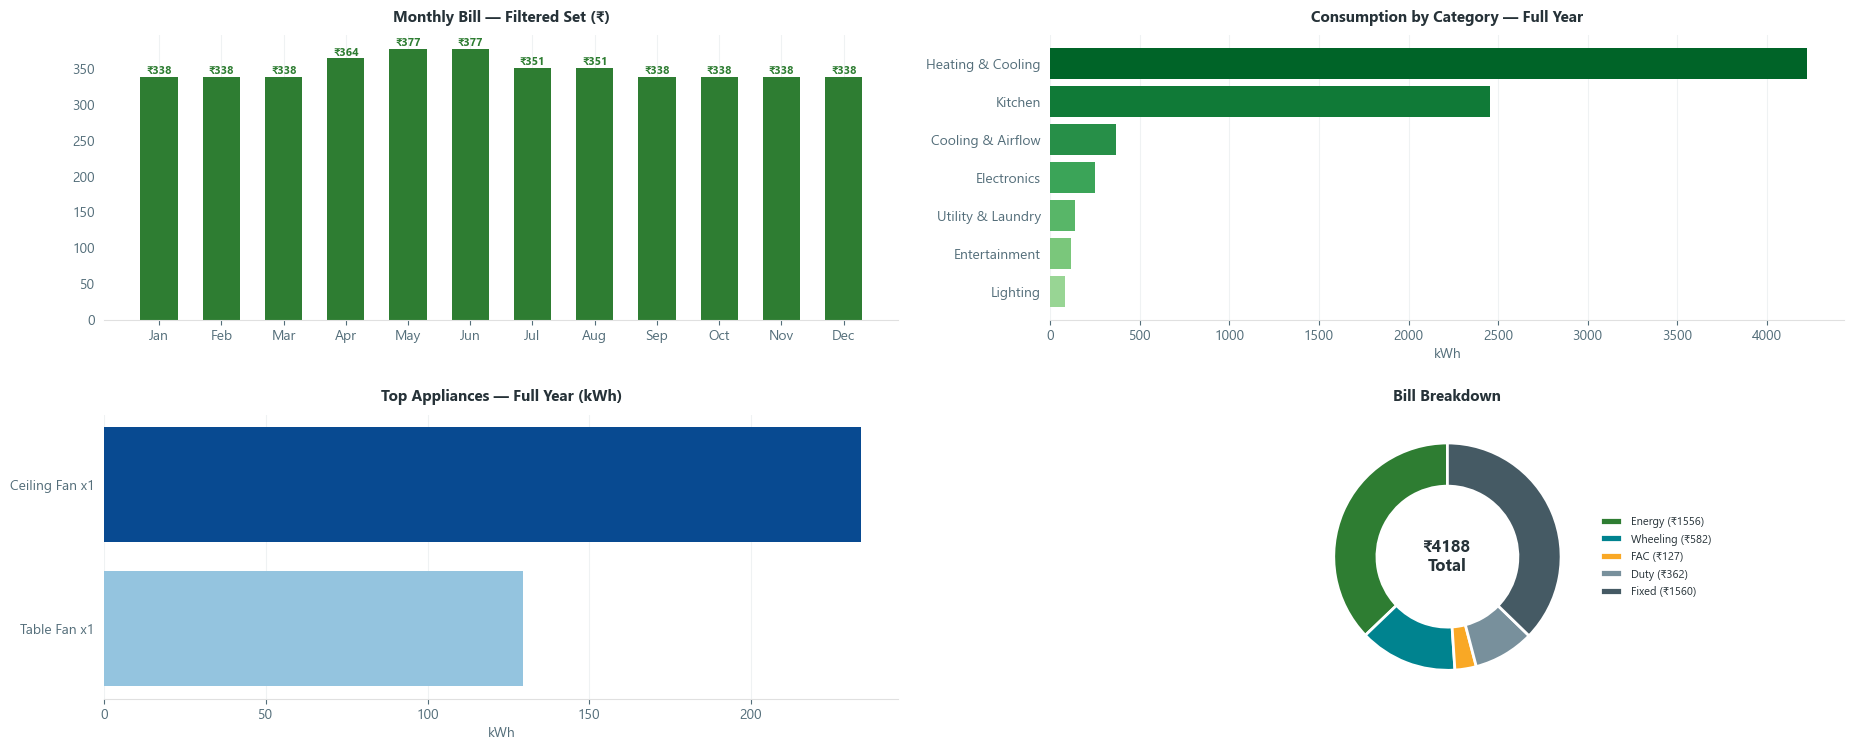

In [75]:
app = ElectricityApp()
app.mainloop()